# 0. Import Dependencies

In [20]:
import sys
import os
import time
from astropy.io import fits
import numpy as np
import glob
import gc
from functools import partial
import matplotlib.pyplot as plt

from SelfCal import PipelineWrapper
from SelfCal.SPHERExUtility import make_fiducial_chunk_map, make_fiducial_chunk_mask, \
load_calibration, make_spherex_offset_map, compute_offsets_guess
from SelfCal.SPHERExAppendWav import wav_coadd

# 1. Self-Cal Run Settings

In [21]:
DETECTOR = 4
config = {}
config['output_dir'] = '/mnt/md124/thomasli/selfcal/outputs/'
config['run_name'] = f'SPHEREx_nep_qr2_det{DETECTOR}_6p2arcsec'
config['resolution_arcsec'] = 6.2

# File structure:

# {output_dir}/
# └── {run_name}/
#     ├── ref.fits                   # Fits file storing the mosaic wcs header
#     ├── reprojected/               # Reprojected exposures
#     │   ├── exp_0000_det_00.h5     # Reprojected exposure where 0000 is exposure ID ranging from 0000 to N-1 and 00 is detector ID
#     │   └── ...
#     ├── calibration/               # Calibration files
#     │   ├── cal_D1_Ch1.h5          # Calibration file for detector 1 channel 1, naming convention defined by Calibrator.save_calibration
#     │   └── ...
#     └── mosaic/                    # Mosaic files
#         ├── mosaic_D1_Ch1.fits     # Mosaic file for detector 1 channel 1, naming convention defined by Mosaicker.save_mosaic
#         └── ...

### Collect Exposures Files

In [22]:
qr1_dir = '/mnt/md124/SPHEREx/SPHEREx_nep_data/qr1_newgain'
qr2_dir = '/mnt/md124/SPHEREx/SPHEREx_nep_data/qr2'
file_pattern = f'/*/*/*/*D{DETECTOR}*.fits'

exposure_list = []
exposure_list += glob.glob(qr1_dir+file_pattern)
exposure_list += glob.glob(qr2_dir+file_pattern)
exposure_list = sorted(exposure_list)

In [23]:
remove_list = []
for exp_file in exposure_list:
    hdul = fits.open(exp_file)
    header = hdul[1].header
    # Check for good astrometry
    good_astrometry = header.get('FINAST', 2)
    if good_astrometry != 0:
        print(f"Skipping {exp_file} due to poor astrometry (FINAST={good_astrometry})")
        exposure_list.remove(exp_file)
        remove_list.append(exp_file)
print(f"Removed {len(remove_list)} exposures with poor astrometry")
print(f"Found {len(exposure_list)} exposures")

Skipping /mnt/md124/SPHEREx/SPHEREx_nep_data/qr1_newgain/2025W18_2B/l2b-v12-2025-164/4/level2_2025W18_2B_0450_4D4_spx_l2b-v12-2025-164.fits due to poor astrometry (FINAST=3)
Skipping /mnt/md124/SPHEREx/SPHEREx_nep_data/qr1_newgain/2025W18_2B/l2b-v12-2025-164/4/level2_2025W18_2B_0503_2D4_spx_l2b-v12-2025-164.fits due to poor astrometry (FINAST=2)
Skipping /mnt/md124/SPHEREx/SPHEREx_nep_data/qr1_newgain/2025W18_2B/l2b-v12-2025-164/4/level2_2025W18_2B_0513_2D4_spx_l2b-v12-2025-164.fits due to poor astrometry (FINAST=2)
Skipping /mnt/md124/SPHEREx/SPHEREx_nep_data/qr1_newgain/2025W20_1C/l2b-v12-2025-175/4/level2_2025W20_1C_0209_2D4_spx_l2b-v12-2025-175.fits due to poor astrometry (FINAST=2)
Skipping /mnt/md124/SPHEREx/SPHEREx_nep_data/qr1_newgain/2025W20_2D/l2b-v12-2025-175/4/level2_2025W20_2D_0567_1D4_spx_l2b-v12-2025-175.fits due to poor astrometry (FINAST=3)
Skipping /mnt/md124/SPHEREx/SPHEREx_nep_data/qr1_newgain/2025W22_2B/l2b-v12-2025-177/4/level2_2025W22_2B_0416_1D4_spx_l2b-v12-2025

# 2. Reprojection

#### Reprojection takes a while, so only run this once for a given set of exposures and detector. If reprojected files already exist in the output directory, this step can be skipped.

#### Reprojector.define_reference needs to be run to set up the reference frame before reprojection. By default, it defines the reference frame so that all input images are fully covered. A reference frame can be chosen manually by providing a fits header by setting Reprojector.config['ref_path'] before calling Reprojector.define_reference.

In [ ]:
# Initialize Reprojector and run reprojection
rr = PipelineWrapper.Reprojector(config, exposure_list=exposure_list)
# Define reference frame with padding
rr.define_reference(padding_pixels=100, use_ext=[1])
# Run reprojection
rr.run_reproject(max_workers=100, # number of parallel workers for reprojection
                 reproj_func='exact', # reprojection function, can be 'exact', 'interp', or 'adaptive' (use 'exact' for best accuracy, 'interp' for speed)
                 padding_percentage=0.05, # percentage of padding around the footprint
                 sci_ext_list=[1], # list of science extensions in the input fits files
                 dq_ext_list=[2], # list of data quality extensions in the input fits files
                 exp_idx_list=np.arange(0, len(exposure_list)), # list of exposure indices
                 det_idx_list=[0]*len(exposure_list), # list of detector indices (0-indexed) corresponding to each exposure
                 replace_existing=False, # whether to replace existing reprojected files
                 reproject_kwargs={'parallel': 4} # additional kwargs for reprojection
                )

Reference WCS not found at /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/ref.fits. Creating a new reference frame.
Defining optimal celestial WCS...
Reprojecting frames:   6%|▉               | 771/13355 [24:21<2:31:51,  1.38it/s]

Loading corner WCS: 100%|█████████████████| 13355/13355 [02:48<00:00, 79.34it/s]


Reference frame FITS saved to: /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/ref.fits
Reference WCS saved to /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/ref.fits
Mosaic shape: (12303, 12437)
Mosaic WCS: WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 268.894044295467 66.55427314033754 
CRPIX : 6359.019507018324 6202.507258222069 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.0017222222222222222 0.0017222222222222222 
NAXIS : 0  0
Starting batch reprojection. Output will be saved to: /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/reprojected


Reprojecting frames:   5%|▊               | 690/13355 [22:19<3:13:31,  1.09it/s]

# 3. Calibration

In [16]:
# Self-calibration parameters

OVERSAMPLE_FACTOR = 2 # Oversampling factor for chunk map, higher values lead to more accurate chunk maps but increase memory usage
NUM_SUBCHANNELS = 10 # Number of sub-channels per channel
NUM_CHANNELS = 34 # Number of channels per detector, must be multiple of 17
FILE_SUFFIX = '' # Suffix for output files
FILE_PREFIX = f'' # Prefix for output files

### Defining Chunk_map

A 'chunk_map' must be defined before running self-calibration. A chunk map is a 2D array with the same shape as the detector images, where each pixel value indicates the sub-channel index that pixel belongs to. The chunk map is used to group pixels into sub-channels for self-calibration with one offset per sub-channel. An oversampled chunk map is used during self-calibration to improve accuracy, while a non-oversampled chunk map is used for final coaddition.

In [17]:
# Load detector band pass
det_BC, det_BW = load_calibration(band=DETECTOR, calibration_dir='/home/thomasli/spherex/SPHEREx_Spectral_Calibration')
# Create chunk maps
chunk_map, lvf_params = make_fiducial_chunk_map(DETECTOR, det_BC, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, 
                                                oversample_factor=OVERSAMPLE_FACTOR)

det_chunk_map, _ = make_fiducial_chunk_map(DETECTOR, det_BC, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS, 
                                           oversample_factor=1, lvf_params=lvf_params)

Fitting LVF parameters...


100%|█████████████████████████████████████████| 341/341 [00:05<00:00, 57.83it/s]


Making chunk map...


100%|█████████████████████████████████████████| 341/341 [00:10<00:00, 33.54it/s]


Making chunk map...


100%|████████████████████████████████████████| 341/341 [00:02<00:00, 138.06it/s]


### Run self-calibration for selected channels

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

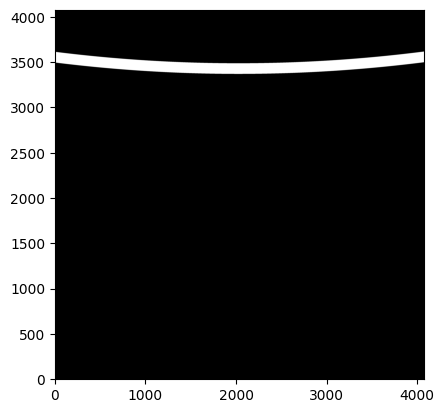

In [18]:
# Define spherex channel to calibrate
ch = [5]

# Chunk_valid_mask selects the subchannels calibrated in each chunk
chunk_valid_mask = make_fiducial_chunk_mask(ch, num_subchannels=NUM_SUBCHANNELS, num_channels=NUM_CHANNELS)
# Det valid_mask selects convert the chunk_valid_mask to detector space
det_valid_mask = chunk_valid_mask[chunk_map]

print(chunk_valid_mask)
plt.imshow(det_valid_mask, origin='lower', cmap='gray')
plt.show()

### Setup Self-Cal sparse matrix

In [19]:
cc = PipelineWrapper.Calibrator(config)
cc.setup_lsqr(
    apply_mask=True, # Whether to apply the bitmask from the original exposure files
    apply_weight=True,  # Whether to apply weights based on pixel values
    chunk_map=chunk_map, 
    det_valid_mask=det_valid_mask, 
    max_workers=40, # Number of parallel workers
    outlier_thresh=10.0, # Outlier threshold in units of sigma, used to reject bright sources
    ignore_list=[], # Index of the dataquality flags to ignore, if empty list, no flags are ignored
    oversample_factor=OVERSAMPLE_FACTOR,
    batch_size=20 # Batch size for task submitted to each worker, lower values means better load balancing but higher overhead,
    
    )


100%|████████████████████████████████| 13454/13454 [00:00<00:00, 1342552.48it/s]

Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det1_6p2arcsec/ref.fits
Processing 13454 items in 673 batches...



Building A, b matrix: 100%|███████████████████| 673/673 [25:58<00:00,  2.32s/it]


LSQR setup completed in 1657.51 seconds.


### Run LSQR

The Self-Cal output is stored in cc['O'] and cc['S']. cc['O'] has the shape (num_exp, num_chunks), and cc['S'] has the shape cc.ref_shape.

In [ ]:
# Provide initial guess for offsets, a first order fit based on mean pixel values in each chunk
offset_guess = compute_offsets_guess(cc.reproj_list, det_chunk_map)

# Reshape initial guess to match lsqr output
x0 = np.hstack([np.zeros(np.prod(cc.ref_shape)), offset_guess.flatten()])

# Run LSQR, same parameters as scipy.sparse.linalg.lsqr
cc.apply_lsqr(x0=x0, atol=1e-06, btol=1e-06, damp=1e-3, iter_lim=200)

# Save calibration results
cal_path = cc.save_calibration(cal_file=f'cal{FILE_PREFIX}_D{DETECTOR}_Ch{"-".join(map(str, ch))}{FILE_SUFFIX}.h5')

# 4. Mosaicking

In [ ]:
mm = PipelineWrapper.Mosaicker(config)
mm.load_calibration(cal_path=cal_path)

# Define the interpolation function that interpolate detector offsets in chunk space to detector space
partial_make_offset_map = partial(make_spherex_offset_map, chunk_valid_mask=chunk_valid_mask, lvf_params=lvf_params)

# Sigma clipping threshold
sc_sigma = 1.0

maps = mm.make_mosaic(
    apply_mask=True, # Whether to apply the bitmask from the original exposure files
    apply_weight=True,  # Whether to apply weights based on pixel values
    chunk_map=chunk_map, 
    det_valid_mask=det_valid_mask, 
    max_workers=40, # Number of parallel workers
    make_std_map=True, # Whether to make standard deviation map
    apply_sigma_clipping=True,  # Whether to make a sigma clipped mosaic
    sigma=sc_sigma,
    ignore_list=[21], # List of dataquality flags to ignore during mosaicking, 21 corresponds to source mask.
    oversample_factor=OVERSAMPLE_FACTOR,
    det_offset_func=partial_make_offset_map,
    cache_batch_size=20, # Batch size for caching intermediate results
    coadd_batch_size=100, # Batch size for coadding intermediate results, coadd after caching is faster so larger batch size is preferred
    cache_dir='/home/thomasli/spherex/selfcal/cache', # Directory to store cached intermediate results
    cache_intermediate=True, # Whether to cache intermediate results, fastest option if apply_std or apply_sigma_clipping is True
    det_aux=None, # Auxiliary detector map, not used here
)

### Append Wavelength Map

In [ ]:
# wav_coadd to produce wavelength maps that indicate the mean and std wavelength in each pixel
wav_mean, wav_std = wav_coadd(det_BC, det_BW, mean_map=maps['mean_map']['data'], std_map=maps['std_map']['data'], 
                                reproj_list=mm.reproj_list, cache_list=mm.cached_list, ref_shape=maps['mean_map']['data'].shape, 
                                sigma=sc_sigma, batch_size=40, max_workers=40)    

# Format wavelength maps and append to mosaic
wav_mean_maps = {'data': wav_mean, 'unit': 'um'}
wav_std_maps = {'data': wav_std, 'unit': 'um'}
mm.append_maps({'wav_mean_map': wav_mean_maps, 'wav_std_map': wav_std_maps})

# Save mosaic
mm.save_mosaic(mos_file=f'mosaic{FILE_PREFIX}_D{DETECTOR}_Ch{"-".join(map(str, ch))}{FILE_SUFFIX}.fits', overwrite=True)